In [1]:
!nvidia-smi

Wed Jul 15 02:36:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [4]:
%pip install --upgrade ultralytics supervision roboflow onnx onnx2tf
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 47.4/235.7 GB disk)


In [5]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg
image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 86.7ms
Speed: 2.6ms preprocess, 86.7ms inference, 19.1ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


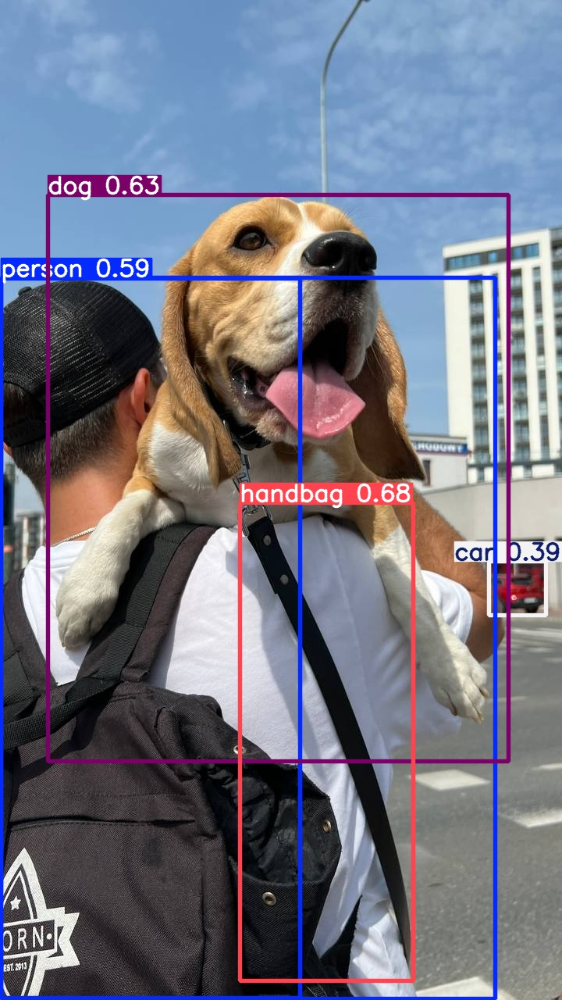

In [6]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

In [7]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 87.4ms
Speed: 3.0ms preprocess, 87.4ms inference, 19.8ms postprocess per image at shape (1, 3, 640, 384)


In [8]:
result.boxes.xyxy

tensor([[3.0704e+02, 6.4338e+02, 5.2918e+02, 1.2559e+03],
        [6.1376e+01, 2.4993e+02, 6.5167e+02, 9.7403e+02],
        [1.7849e+00, 3.5550e+02, 6.3408e+02, 1.2788e+03],
        [1.1948e+00, 3.5621e+02, 3.8468e+02, 1.2776e+03],
        [6.2615e+02, 7.1817e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [9]:
result.boxes.conf

tensor([0.6826, 0.6284, 0.5940, 0.3920, 0.3866], device='cuda:0')

In [10]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

In [11]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

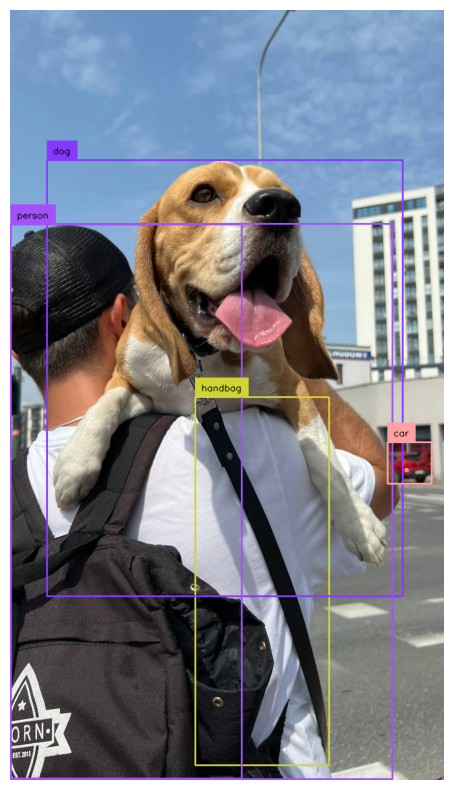

In [12]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

In [13]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("renaire-odarve")
project = workspace.project("erotica-detection")
version = project.version(7) # version of dataset in roboflow
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to erotica-detection-7 in yolov11:: 100%|██████████| 56800/56800 [00:06<00:00, 8178.12it/s] 


In [14]:
%cd {HOME}

# !yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=150 imgsz=768 plots=True # previous epoch: 10

# !yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml \
# epochs=50 imgsz=640 batch=16 lr0=0.003 lrf=0.01 optimizer=AdamW \
# momentum=0.937 weight_decay=0.0005 warmup_epochs=5 \
# freeze=0 patience=30 cos_lr=True \
# box=7.5 cls=1.0 dfl=1.5 \
# hsv_h=0.015 hsv_s=0.7 hsv_v=0.4 mosaic=1.0 mixup=0.1 fliplr=0.5 \
# plots=True

# !yolo task=detect mode=train model=yolo11s.pt \
# data={dataset.location}/data.yaml \
# epochs=100 imgsz=768 batch=32 \
# lr0=0.002 lrf=0.01 optimizer=AdamW \
# momentum=0.937 weight_decay=0.0005 \
# warmup_epochs=3 \
# freeze=0 \
# patience=30 cos_lr=True \
# mosaic=0.5 mixup=0.02 fliplr=0.5 \
# hsv_h=0.015 hsv_s=0.4 hsv_v=0.4 \
# plots=True

# !yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml \
# epochs=150 imgsz=768 batch=120 lr0=0.0025 optimizer=SGD \
# freeze=2 patience=30 cos_lr=True \
# plots=True

!yolo task=detect mode=train model=yolo11s.pt \
data={dataset.location}/data.yaml \
epochs=150 imgsz=640 batch=64 \
lr0=0.003 lrf=0.01 optimizer=SGD \
momentum=0.937 weight_decay=0.0005 \
warmup_epochs=3 \
freeze=0 \
patience=0 cos_lr=True \
mosaic=1.0 mixup=0.05 fliplr=0.5 \
hsv_h=0.015 hsv_s=0.5 hsv_v=0.4 \
plots=True


/content
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/erotica-detection-7/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize

In [15]:
%load_ext tensorboard
%tensorboard --logdir /content/runs/detect

<IPython.core.display.Javascript object>

In [16]:
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg      val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch43680.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch43681.jpg  weights
labels.jpg			 train_batch43682.jpg


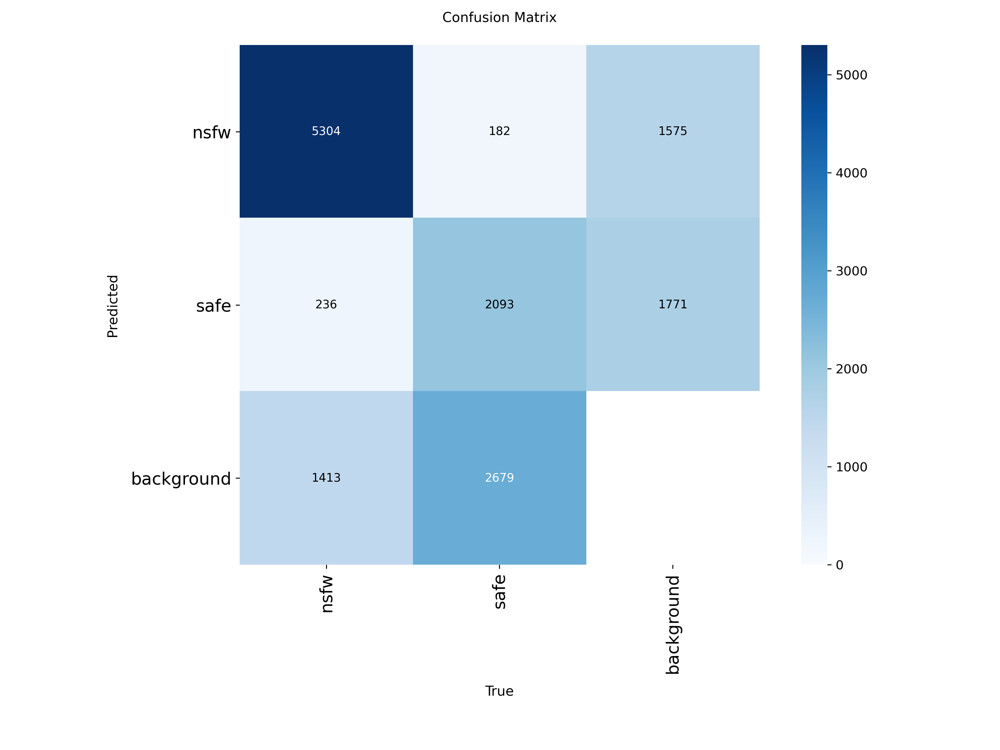

In [17]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

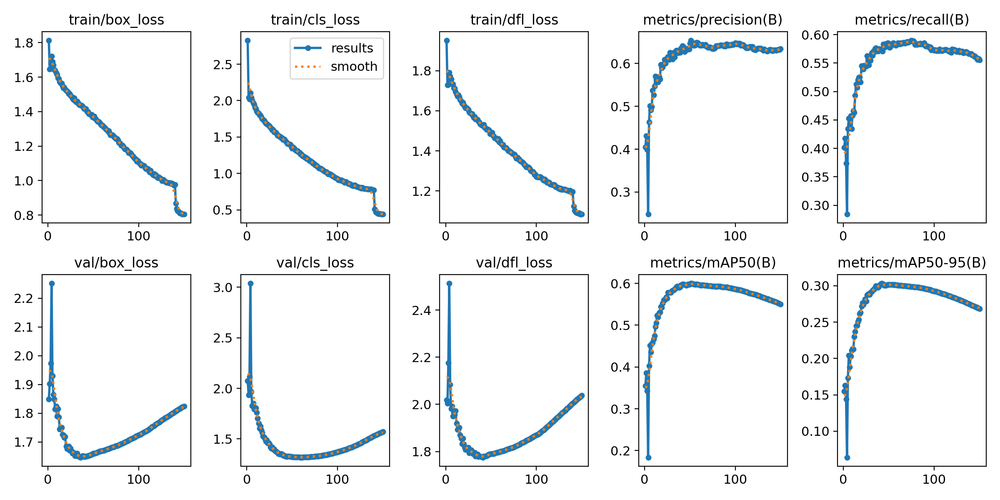

In [18]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

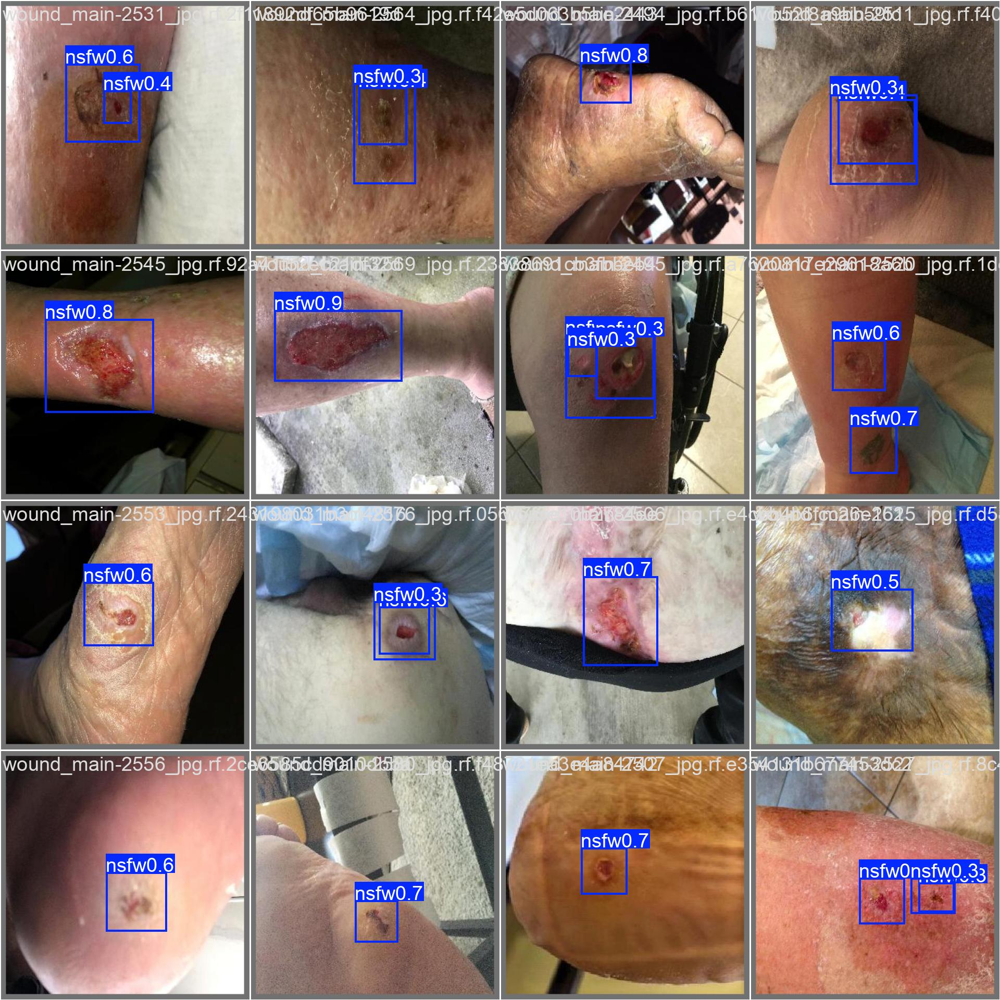

In [19]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [20]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1583.8±663.0 MB/s, size: 40.4 KB)
val: Scanning /content/datasets/erotica-detection-7/valid/labels.cache... 7130 images, 809 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7130/7130 1.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 446/446 12.3it/s 36.1s
                   all       7130      11907       0.64      0.576      0.598      0.303
                  nsfw       4284       6953      0.757      0.746      0.788      0.423
                  safe       2266       4954      0.523      0.406      0.407      0.183
Speed: 0.6ms preprocess, 1.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [21]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/1333 /content/datasets/erotica-detection-7/test/images/03b88657f87cbb2c354ef68cc10ab04ea69b7ebfaae0732636cab1002433302a_jpg.rf.ecf1d5d435b547824a062b744d122ca0.jpg: 640x640 1 safe, 9.8ms
image 2/1333 /content/datasets/erotica-detection-7/test/images/04da2eabce826e56060ecb6c101c0034ffe62e90945bf972573890c5613ec18b_jpg.rf.1dfb3ec6db31a8b37e6157b6e2280dff.jpg: 640x640 (no detections), 10.3ms
image 3/1333 /content/datasets/erotica-detection-7/test/images/05101c6861a7fd415b497eb4245bc04d149aad7f637ac361e60c8860a1cad774_jpg.rf.496e2e08d188cbd9558189ab54f48c40.jpg: 640x640 6 safes, 9.6ms
image 4/1333 /content/datasets/erotica-detection-7/test/images/0527c86389462249_jpg.rf.7fe1faba250da9f4518e8119c18044f8.jpg: 640x640 2 safes, 9.8ms
image 5/1333 /content/datasets/erotica-detection-7/test/images/06d61dc1cc34

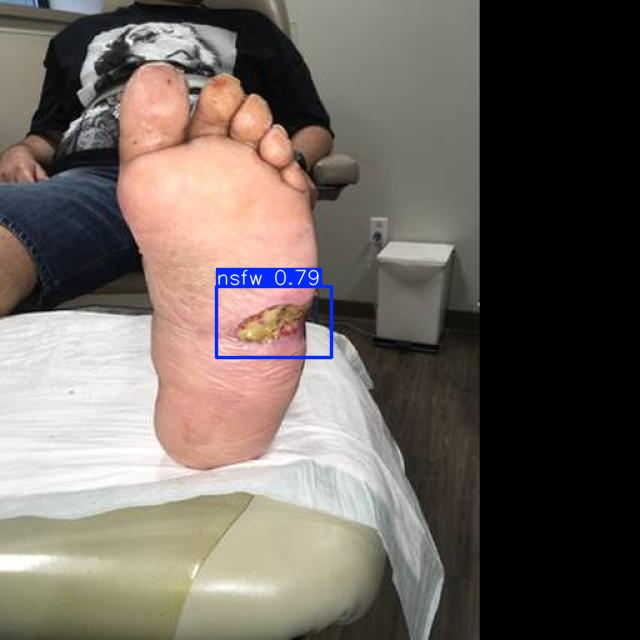

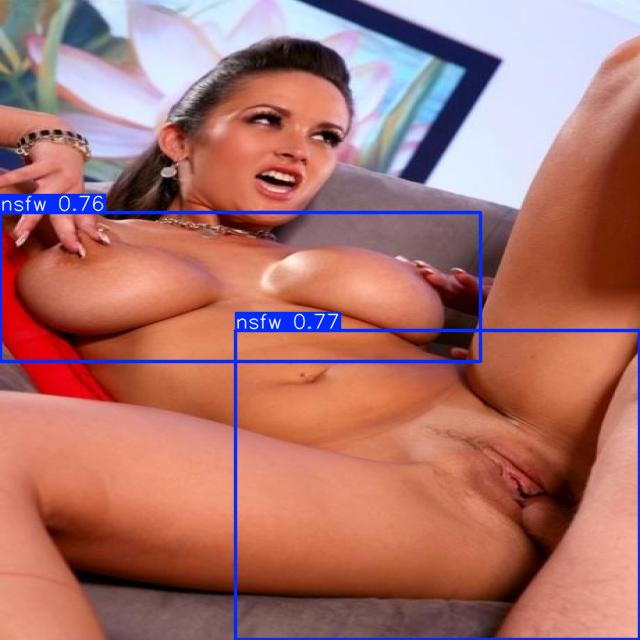

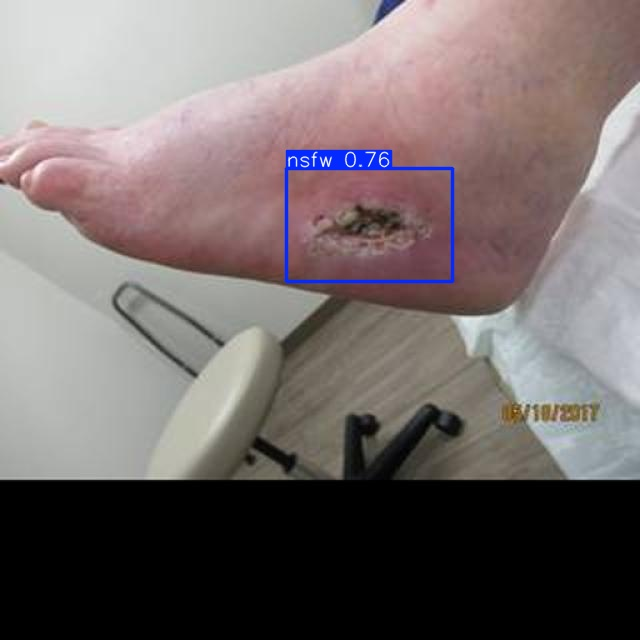

In [22]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [23]:
model.export(format="tflite",
             data="content/datasets/erotica-detection-7/data.yaml")

# Zip the results and weights folder
!zip -r yolov11n_results.zip /content/runs/detect/train/

# Zip the saved models folder
!zip -r yolov11n_saved_model.zip /content/yolo11n_saved_model

from google.colab import files

files.download('yolov11n_results.zip')
files.download('yolov11n_saved_model.zip')

WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert/
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)
requirements: Ultralytics requirements ['litert-torch>=0.9.0', 'ai-edge-litert>=2.1.4'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 85 packages in 636ms
Prepared 14 packages in 2.37s
Uninstalled 4 packages in 28ms
Installed 14 packages in 17ms
 - ai-edge-litert==2.1.2
 + ai-edge-litert==2.1.5
 + ai-edge-quantizer==0.7.0
 + fire==0.7.1
 - immutabledict==4.3.1
 + immutabledict==4.2.1
 + jaxtyping==0.3.11
 +

invalid escape sequence '\.'



LiteRT: starting export with litert_torch 0.9.1...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:00) [ DONE] Write Model to yolo11n.tflite (+00:00)

LiteRT: export success ✅ 23.0s, saved as 'yolo11n.tflite' (10.3 MB)

Export complete (23.3s)
Results saved to /content/yolo11n.tflite
Predict:         yolo predict task=detect model=yolo11n.tflite imgsz=640 
Validate:        yolo val task=detect model=yolo11n.tflite imgsz=640 data=/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/val_batch1_labels.jpg (deflated 7%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/best.pt (deflated 8%)
  adding: content/runs/detect/train/weights/last.pt (deflated 8%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 30%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflated 7%)
  adding: content/runs/detect/train/val_batch1_pred.jpg (deflated 7%)
  adding: content/runs/detect/train/train_batch0.jpg (deflated 2%)
  adding: content/runs/d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: yolov11n_saved_model.zip